# Amazon Comprehend — 심화 도전 해답 모음 (Lab 1~5)

각 Lab '💡 심화 도전' 문제의 **해답**입니다. 코드형 문제는 실행 가능한 코드로, 설계형 문제는 **설명 + 예시 코드**로 풀이했습니다.

> ⚙️ **실행 안내**
> - **AWS 호출 셀**(Comprehend API)은 SageMaker Studio에서 실행하세요.
> - **군집(sklearn) 셀**은 인터넷만 되면 로컬에서도 실행됩니다.
> - 리전: 한국어 기능 → 서울(`comp_kr`), 영어 전용(대상감성·PII) → 버지니아(`comp_us`).

In [1]:
# ✅ 공통 환경 초기화
import boto3, json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

try:
    import koreanize_matplotlib
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'koreanize-matplotlib'])
    import koreanize_matplotlib
try:
    import sklearn
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'scikit-learn'])

comp_kr = boto3.client('comprehend', region_name='ap-northeast-2')  # 한국어 지원 기능
comp_us = boto3.client('comprehend', region_name='us-east-1')       # 대상감성·PII(영어 전용)
print('✅ 환경 초기화 완료')

✅ 환경 초기화 완료


---
# Lab 1 — 언어 감지 & 감성 분석

### 도전 1. 영어 텍스트와 한국어 텍스트의 감성 분석 결과 비교
같은 의미의 문장을 한국어/영어로 각각 분석해 점수를 비교합니다.

In [2]:
pairs = [
    ('이 제품 정말 최고예요! 완전 만족합니다.', 'This product is the best! Totally satisfied.'),
    ('완전 실망이에요. 다시는 안 살 거예요.',   'Totally disappointed. I will never buy again.'),
    ('그냥 평범해요. 나쁘지도 좋지도 않아요.',   "It's just average. Neither good nor bad."),
]
rows = []
for ko, en in pairs:
    rk = comp_kr.detect_sentiment(Text=ko, LanguageCode='ko')
    re_ = comp_kr.detect_sentiment(Text=en, LanguageCode='en')
    rows.append({
        '문장': ko[:18],
        'KO_감성': rk['Sentiment'], 'KO_Pos': round(rk['SentimentScore']['Positive'], 3),
        'EN_감성': re_['Sentiment'], 'EN_Pos': round(re_['SentimentScore']['Positive'], 3),
    })
print(pd.DataFrame(rows).to_string(index=False))
# 관찰: 의미가 같아도 언어별로 점수가 미묘하게 다를 수 있습니다(특히 중립/혼합 경계).

                문장    KO_감성  KO_Pos    EN_감성  EN_Pos
이 제품 정말 최고예요! 완전 만 POSITIVE   1.000 POSITIVE   1.000
완전 실망이에요. 다시는 안 살  NEGATIVE   0.000 NEGATIVE   0.000
그냥 평범해요. 나쁘지도 좋지도  NEGATIVE   0.024    MIXED   0.096


### 도전 2. 부정 리뷰만 필터링 → Confidence(부정 점수) 내림차순 정렬

In [3]:
reviews = [
    '배송도 빠르고 품질도 최고예요!', '사진과 너무 달라서 정말 실망했어요',
    '그냥 그래요 보통입니다', '환불 절차가 복잡하고 너무 화나네요',
    '재구매 의사 있어요 만족합니다', '포장이 엉망이고 제품도 불량이에요',
    '가성비 좋네요', '주문한 지 2주째 배송이 안 와서 최악입니다',
    '색상이 예뻐요', '상담원이 불친절해서 기분 나빴어요',
]
resp = comp_kr.batch_detect_sentiment(TextList=reviews, LanguageCode='ko')

negatives = [
    {'review': reviews[r['Index']], 'neg_score': r['SentimentScore']['Negative']}
    for r in resp['ResultList'] if r['Sentiment'] == 'NEGATIVE'
]
negatives.sort(key=lambda x: x['neg_score'], reverse=True)

print('🚨 부정 리뷰 (확신도 높은 순) — CS 우선 대응 큐:')
for n in negatives:
    print(f"  {n['neg_score']:.3f}  {n['review']}")

🚨 부정 리뷰 (확신도 높은 순) — CS 우선 대응 큐:
  1.000  포장이 엉망이고 제품도 불량이에요
  1.000  사진과 너무 달라서 정말 실망했어요
  1.000  환불 절차가 복잡하고 너무 화나네요
  0.999  주문한 지 2주째 배송이 안 와서 최악입니다
  0.999  상담원이 불친절해서 기분 나빴어요


### 도전 3. 상품 리뷰 10개 → 긍정/부정 비율 파이차트

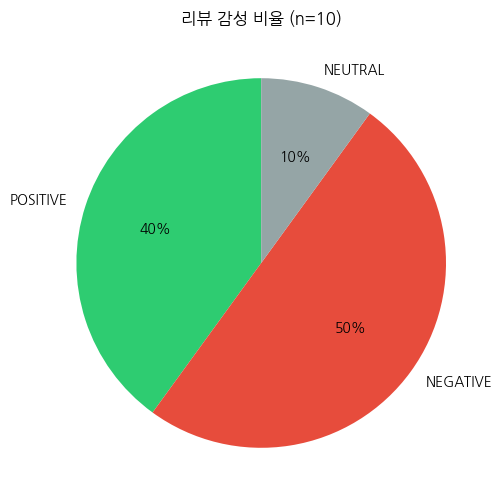

In [4]:
resp = comp_kr.batch_detect_sentiment(TextList=reviews, LanguageCode='ko')
counts = Counter(r['Sentiment'] for r in resp['ResultList'])

colors = {'POSITIVE': '#2ecc71', 'NEGATIVE': '#e74c3c', 'NEUTRAL': '#95a5a6', 'MIXED': '#f39c12'}
plt.figure(figsize=(6, 6))
plt.pie(counts.values(), labels=counts.keys(),
        colors=[colors[k] for k in counts.keys()], autopct='%1.0f%%', startangle=90)
plt.title('리뷰 감성 비율 (n=%d)' % len(reviews))
plt.show()

---
# Lab 2 — 개체 인식(NER) & 핵심 문구

### 도전 1. 같은 인물이 여러 번 언급될 때 중복 제거 후 집계

In [5]:
text = '''
이재용 회장은 오늘 기자회견을 열었다. 이재용 회장은 신제품을 직접 소개했으며,
정의선 회장도 행사에 참석했다. 이재용 회장의 발표 이후 정의선 회장이 축사를 했다.
'''
ents = comp_kr.detect_entities(Text=text, LanguageCode='ko')['Entities']
persons = [e['Text'] for e in ents if e['Type'] == 'PERSON']

print('원본 PERSON 언급 :', persons)
print('인물별 언급 횟수 :', dict(Counter(persons)))
print('고유 인물 수     :', len(set(persons)))

원본 PERSON 언급 : ['이재용', '회장', '이재용', '회장', '정의선', '회장', '이재용', '회장', '정의선', '회장']
인물별 언급 횟수 : {'이재용': 3, '회장': 5, '정의선': 2}
고유 인물 수     : 3


### 도전 2. LOCATION 개체만 추출 → folium 지도 시각화 설계
**설계:** ① Comprehend로 LOCATION 추출 → ② 지오코딩(geopy 등)으로 위·경도 변환 → ③ folium 지도에 마커 표시. 지오코딩은 외부 서비스가 필요하므로 아래는 구조 예시입니다.

In [6]:
!pip install geopy folium

   ━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━ 3/5 [branca]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [folium]


In [8]:
news = '''
삼성전자는 서울 강남구에 새 사옥을 열었고, 부산과 대구에도 지점을 확장했다.
미국 뉴욕과 일본 도쿄에도 진출할 계획이다.
'''
ents = comp_kr.detect_entities(Text=news, LanguageCode='ko')['Entities']
locations = sorted({e['Text'] for e in ents if e['Type'] == 'LOCATION'})
print('추출된 LOCATION:', locations)

# --- folium 지도 시각화 설계 (실행하려면 geopy, folium 설치 필요) ---
from geopy.geocoders import Nominatim
import folium
geo = Nominatim(user_agent='comprehend-demo')
m = folium.Map(location=[36.5, 127.8], zoom_start=3)
for loc in locations:
    g = geo.geocode(loc)               # 지명 → 위경도
    if g:
        folium.Marker([g.latitude, g.longitude], popup=loc).add_to(m)
m.save('locations_map.html')
print('→ 위 LOCATION을 지오코딩해 folium.Marker로 찍으면 언급 지역 지도가 완성됩니다.')

추출된 LOCATION: ['대구', '미국 뉴욕', '부산', '서울 강남구', '일본 도쿄']


→ 위 LOCATION을 지오코딩해 folium.Marker로 찍으면 언급 지역 지도가 완성됩니다.


### 도전 3. 뉴스 5개 → 가장 많이 등장하는 ORGANIZATION 순위

In [9]:
articles = [
    '삼성전자와 애플의 경쟁이 치열하다. 삼성전자가 신제품을 발표했다.',
    'LG전자가 신가전을 공개했고, 삼성전자도 맞대응에 나섰다.',
    '현대차와 기아가 전기차 판매를 늘렸다. 현대차의 성장세가 돋보인다.',
    '네이버와 카카오가 AI 투자를 확대한다. 네이버가 신모델을 공개했다.',
    '삼성전자, 현대차, 네이버가 나란히 호실적을 기록했다.',
]
org = Counter()
for a in articles:
    for e in comp_kr.detect_entities(Text=a, LanguageCode='ko')['Entities']:
        if e['Type'] == 'ORGANIZATION':
            org[e['Text']] += 1

print('🏢 ORGANIZATION 언급 순위:')
for name, cnt in org.most_common():
    print(f'  {cnt}회  {name}')

🏢 ORGANIZATION 언급 순위:
  4회  삼성전자
  3회  현대차
  3회  네이버
  1회  애플
  1회  LG전자
  1회  기아
  1회  카카오


---
# Lab 3 — 대상 감성 & PII

### 도전 1. detect_sentiment(전체) vs detect_targeted_sentiment(개체별) 비교

In [10]:
review = ("The camera quality is excellent, but the battery life is terrible "
          "and the price is too high.")

overall = comp_us.detect_sentiment(Text=review, LanguageCode='en')
print('▶ 전체 감성(detect_sentiment):', overall['Sentiment'])
print('   →', {k: round(v, 2) for k, v in overall['SentimentScore'].items()})

print('\n▶ 개체별 감성(detect_targeted_sentiment):')
tg = comp_us.detect_targeted_sentiment(Text=review, LanguageCode='en')
for e in tg['Entities']:
    m = e['Mentions'][0]
    print(f"   {m['Text']:<15} → {m['MentionSentiment']['Sentiment']}")
print('\n해석: 전체는 하나로 뭉뚱그려지지만, 대상 감성은 camera=긍정 / battery·price=부정으로 분리됩니다.')

▶ 전체 감성(detect_sentiment): MIXED
   → {'Positive': 0.0, 'Negative': 0.0, 'Neutral': 0.0, 'Mixed': 1.0}

▶ 개체별 감성(detect_targeted_sentiment):


   camera          → POSITIVE
   quality         → POSITIVE
   battery         → NEGATIVE
   price           → NEGATIVE

해석: 전체는 하나로 뭉뚱그려지지만, 대상 감성은 camera=긍정 / battery·price=부정으로 분리됩니다.


### 도전 2. 고객 상담 로그 PII 마스킹 배치 파이프라인
**설계:** `원본 로그(S3)` → `Lambda(detect_pii_entities + 마스킹)` → `안전한 로그(S3)`. 핵심 마스킹 함수는 아래와 같습니다.

In [11]:
def mask_pii(text):
    """텍스트에서 PII를 [TYPE]으로 치환"""
    ents = comp_us.detect_pii_entities(Text=text, LanguageCode='en')['Entities']
    masked = text
    for e in sorted(ents, key=lambda x: x['BeginOffset'], reverse=True):  # 뒤에서부터 치환(offset 보존)
        masked = masked[:e['BeginOffset']] + f"[{e['Type']}]" + masked[e['EndOffset']:]
    return masked

logs = [
    "Hi, this is John Smith, call me at 555-123-4567 or john@email.com.",
    "My card 4532-1234-5678-9012 was charged twice, SSN 123-45-6789.",
]
print('🔒 배치 마스킹 결과:')
for log in logs:
    print('  before:', log)
    print('  after :', mask_pii(log), '\n')

# 실무 배치 파이프라인(개념):
#   S3(raw) --upload event--> Lambda(mask_pii) --> S3(clean) --> 분석팀 사용
#   * 분석팀은 마스킹된 데이터만 받으므로 개인정보보호법 위반 위험 제거

🔒 배치 마스킹 결과:
  before: Hi, this is John Smith, call me at 555-123-4567 or john@email.com.


  after : Hi, this is [NAME], call me at [PHONE] or [EMAIL]. 

  before: My card 4532-1234-5678-9012 was charged twice, SSN 123-45-6789.


  after : My card [CREDIT_DEBIT_NUMBER] was charged twice, SSN [SSN]. 



### 도전 3. PII 유형별 빈도 집계 — 어떤 PII가 가장 많이 노출되나

PII 유형별 빈도: {'NAME': 2, 'EMAIL': 3, 'PHONE': 2, 'ADDRESS': 1, 'CREDIT_DEBIT_NUMBER': 1, 'SSN': 1}


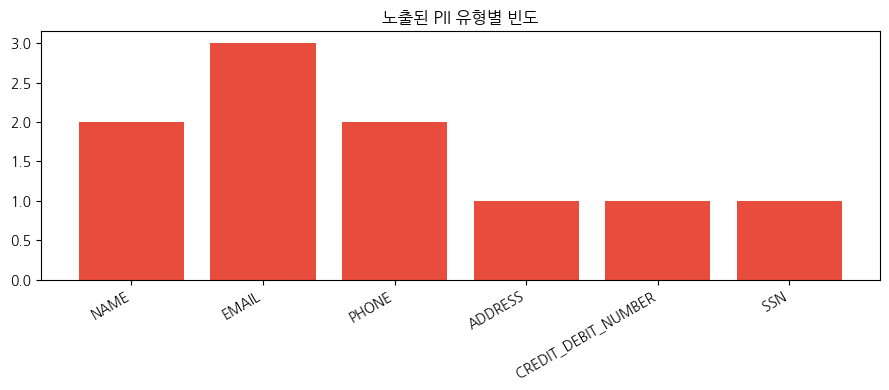

In [12]:
texts = [
    "Name: John Smith, Email: john@email.com, Phone: 555-1234",
    "Contact Jane at jane@email.com or 555-5678. Address: 1 Main St.",
    "Card 4532-1234-5678-9012, SSN 123-45-6789, email bob@email.com",
]
pii_types = Counter()
for t in texts:
    for e in comp_us.detect_pii_entities(Text=t, LanguageCode='en')['Entities']:
        pii_types[e['Type']] += 1

print('PII 유형별 빈도:', dict(pii_types))
plt.figure(figsize=(9, 4))
plt.bar(pii_types.keys(), pii_types.values(), color='#e74c3c')
plt.title('노출된 PII 유형별 빈도')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
# Lab 4 — 구문 분석 & 종합 파이프라인

### 도전 1. 뉴스 10개 → 날짜별 감성 트렌드 꺾은선 그래프

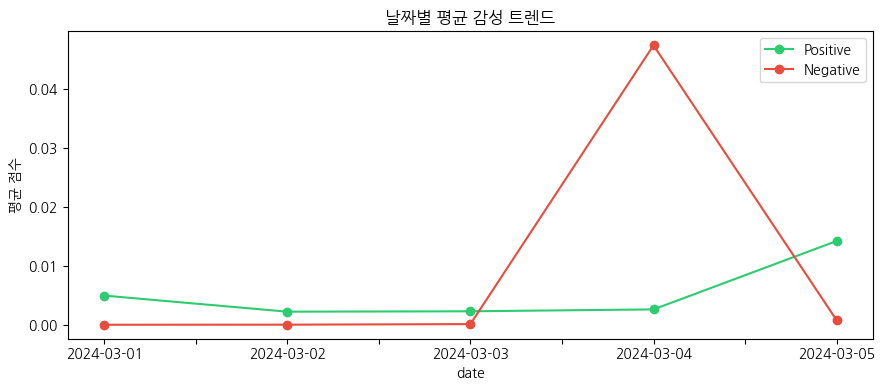

In [16]:
#news = [
#    ('2024-03-01', '신제품 출시로 매출이 크게 늘며 기대감이 커지고 있다'),
#    ('2024-03-01', '일부 소비자는 가격이 비싸다며 불만을 토로했다'),
#    ('2024-03-02', '품질 논란이 불거지며 부정 여론이 확산되고 있다'),
#    ('2024-03-02', '회사가 빠르게 리콜을 결정해 신뢰를 회복했다'),
#    ('2024-03-03', '실적 호조로 주가가 상승하며 투자자들이 환호했다'),
#    ('2024-03-03', '경쟁사 대비 우위를 점했다는 긍정 평가가 이어졌다'),
#    ('2024-03-04', '공급 차질로 배송 지연 불만이 늘고 있다'),
#    ('2024-03-04', '서비스 개선 발표로 분위기가 다시 좋아졌다'),
#    ('2024-03-05', '신규 파트너십 체결로 전망이 밝아지고 있다'),
#    ('2024-03-05', '일부 기능 오류로 사용자 불만이 제기됐다'),
#]

#테스트용으로 기업(ORGANIZATION) 이름이 명확히 포함된 데이터로 변경
news = [
    ('2024-03-01', '삼성전자가 새로운 AI 가전 라인업을 공개하며 시장 선점에 나섰다.'),
    ('2024-03-02', '현대자동차와 기아는 올해 북미 시장에서 역대 최고 판매량을 기록했다.'),
    ('2024-03-03', '네이버와 카카오는 생성형 AI 서비스 경쟁을 본격화하고 있다.'),
    ('2024-03-04', '구글과 마이크로소프트의 클라우드 서비스 점유율 싸움이 치열하다.'),
    ('2024-03-05', '삼성전자의 주가가 실적 호조 기대로 연일 상승세를 이어가고 있다.')
]

rows = []
for date, headline in news:
    s = comp_kr.detect_sentiment(Text=headline, LanguageCode='ko')['SentimentScore']
    rows.append({'date': date, 'Positive': s['Positive'], 'Negative': s['Negative']})

df = pd.DataFrame(rows).groupby('date')[['Positive', 'Negative']].mean()
df.plot(marker='o', figsize=(9, 4), color={'Positive': '#2ecc71', 'Negative': '#e74c3c'})
plt.title('날짜별 평균 감성 트렌드')
plt.ylabel('평균 점수')
plt.tight_layout()
plt.show()

### 도전 2. 가장 많이 언급된 ORGANIZATION Top 5

In [17]:
org = Counter()
for _, headline in news:
    for e in comp_kr.detect_entities(Text=headline, LanguageCode='ko')['Entities']:
        if e['Type'] == 'ORGANIZATION':
            org[e['Text']] += 1
print('ORGANIZATION Top 5:', org.most_common(5))
# (헤드라인에 조직명이 적으면 결과가 비어 있을 수 있습니다 → 기사 본문을 넣으면 풍부해집니다.)

ORGANIZATION Top 5: [('삼성전자', 2), ('현대자동차', 1), ('기아', 1), ('네이버', 1), ('카카오', 1)]


### 도전 3. 파이프라인을 Lambda로 배포하는 아키텍처 설계
**아키텍처:** `S3 업로드(또는 API Gateway)` → `Lambda(Comprehend 호출)` → `DynamoDB 저장` → `대시보드`. Lambda 핸들러 예시는 아래와 같습니다.

In [18]:
# lambda_function.py (배포용 예시 — 노트북에서 실행하는 코드가 아닙니다)
LAMBDA_CODE = '''
import boto3, json
comprehend = boto3.client('comprehend')

def lambda_handler(event, context):
    text = event.get('text', '')
    sent = comprehend.detect_sentiment(Text=text, LanguageCode='ko')
    ents = comprehend.detect_entities(Text=text, LanguageCode='ko')['Entities']
    result = {
        'sentiment': sent['Sentiment'],
        'entities': [e['Text'] for e in ents if e['Type'] == 'ORGANIZATION'],
    }
    # TODO: DynamoDB 등에 result 저장
    return {'statusCode': 200, 'body': json.dumps(result, ensure_ascii=False)}
'''
print(LAMBDA_CODE)
print('배포 단계: ① IAM 역할에 ComprehendReadOnly 부여 ② Lambda 함수 생성 ③ '
      'API Gateway 또는 S3 이벤트 트리거 연결 ④ DynamoDB 결과 적재 → 대시보드')


import boto3, json
comprehend = boto3.client('comprehend')

def lambda_handler(event, context):
    text = event.get('text', '')
    sent = comprehend.detect_sentiment(Text=text, LanguageCode='ko')
    ents = comprehend.detect_entities(Text=text, LanguageCode='ko')['Entities']
    result = {
        'sentiment': sent['Sentiment'],
        'entities': [e['Text'] for e in ents if e['Type'] == 'ORGANIZATION'],
    }
    # TODO: DynamoDB 등에 result 저장
    return {'statusCode': 200, 'body': json.dumps(result, ensure_ascii=False)}

배포 단계: ① IAM 역할에 ComprehendReadOnly 부여 ② Lambda 함수 생성 ③ API Gateway 또는 S3 이벤트 트리거 연결 ④ DynamoDB 결과 적재 → 대시보드


---
# Lab 5 — 토픽 모델링 & 비지도 군집  (sklearn, 로컬 실행 가능)

In [19]:
# Lab 5 기본 데이터·벡터라이저 재정의 (해답 셀에서 공통 사용)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

sample_docs = [
    '배송 속도가 느리고 배송이 일주일 걸렸어요', '배송 박스가 찌그러져서 왔어요',
    '배송 빨라서 좋고 당일 배송 편리해요', '배송 기사님 친절하고 배송 상태 좋아요',
    '제품 품질이 사진과 달라 품질 실망이에요', '원단 품질 훌륭하고 품질 튼튼해요',
    '품질 금방 망가지고 품질 별로예요', '마감 품질 깔끔하고 품질 만족해요',
    '가격 비싸고 환불 원하는데 환불 안돼요', '가격 합리적이고 가격 가성비 좋아요',
    '환불 절차 복잡하고 환불 느려요', '할인 가격 저렴해서 가격 만족해요',
    '상담 직원이 불친절하고 상담 별로예요', '상담 답변 빠르고 상담 친절해요',
    '상담 연결 오래 걸리고 상담 불편해요', '고객센터 상담 만족하고 상담 좋아요',
]
STOPWORDS = ['너무','정말','아주','매우','그냥','좋아요','좋고','걸렸어요','걸리고','왔어요',
             '만족해요','편리해요','친절해요','달라','안돼요','원하는데','저렴해서','빠르고',
             '느리고','느려요','복잡하고','깔끔하고','훌륭하고','튼튼해요','불친절하고','별로예요',
             '실망이에요','망가지고','찌그러져서']
vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b", stop_words=STOPWORDS)
X = vectorizer.fit_transform(sample_docs)
print('문서', X.shape[0], '| 단어', X.shape[1])

문서 16 | 단어 32


### 도전 1. NUM_TOPICS를 3, 4, 5, 6으로 바꿔가며 군집 비교 (실루엣 점수)

In [20]:
from sklearn.metrics import silhouette_score
print('K별 군집 품질 비교:')
for k in [3, 4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    sizes = dict(sorted(Counter(labels).items()))
    print(f'  K={k} | 실루엣={sil:.3f} | 군집 크기={sizes}')
print('\n→ 실루엣 점수가 가장 높은 K가 보통 가장 자연스러운 군집 수입니다 (여기선 4 부근).')

# 실루엣 점수(Silhouette Score)는 군집화(Clustering) 모델이 "그룹을 얼마나 잘 나누었는가"를 평가하는 대표적인 지표입니다.
# 쉽게 말해, 데이터들이 자기 그룹 멤버들과는 얼마나 가깝게 뭉쳐있고, 다른 그룹 멤버들과는 얼마나 멀리 떨어져 있는지를 계산해 점수로 나타낸 것입니다.

K별 군집 품질 비교:
  K=3 | 실루엣=0.197 | 군집 크기={0: 8, 1: 4, 2: 4}
  K=4 | 실루엣=0.250 | 군집 크기={0: 4, 1: 4, 2: 4, 3: 4}
  K=5 | 실루엣=0.294 | 군집 크기={0: 4, 1: 2, 2: 4, 3: 4, 4: 2}
  K=6 | 실루엣=0.278 | 군집 크기={0: 4, 1: 2, 2: 3, 3: 4, 4: 2, 5: 1}

→ 실루엣 점수가 가장 높은 K가 보통 가장 자연스러운 군집 수입니다 (여기선 4 부근).


### 도전 2. 실제 리뷰 30개 입력 → 토픽 추출

In [21]:
reviews30 = [
    '배송이 정말 빨라요', '배송 박스 찌그러짐', '배송 또 지연됐어요', '당일 배송 최고',
    '배송 기사님 친절', '배송 포장 꼼꼼', '배송 일주일 걸림', '배송 상태 양호',
    '품질 너무 좋아요', '품질 사진과 다름', '품질 금방 망가짐', '원단 품질 우수',
    '마감 품질 별로', '품질 대비 만족', '품질 튼튼해요', '품질 실망',
    '가격 합리적', '가격 너무 비쌈', '환불 처리 느림', '환불 절차 복잡',
    '할인 가격 만족', '가성비 최고', '환불 거부당함', '가격 적당',
    '상담원 친절', '상담 연결 지연', '상담 불친절', '상담 답변 빠름',
    '고객센터 만족', '상담 응대 별로',
]
vec30 = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b")
X30 = vec30.fit_transform(reviews30)
km30 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels30 = km30.fit_predict(X30)

terms = vec30.get_feature_names_out()
for c in range(4):
    top = km30.cluster_centers_[c].argsort()[::-1][:4]
    members = [reviews30[i] for i in range(len(reviews30)) if labels30[i] == c]
    print(f"토픽 {c} 대표어 {[terms[i] for i in top]} | 리뷰 {len(members)}건")

토픽 0 대표어 ['배송', '상담', '최고', '친절'] | 리뷰 15건
토픽 1 대표어 ['가격', '합리적', '적당', '할인'] | 리뷰 4건
토픽 2 대표어 ['품질', '튼튼해요', '실망', '대비'] | 리뷰 8건
토픽 3 대표어 ['환불', '거부당함', '절차', '느림'] | 리뷰 3건


### 도전 3. 토픽별 평균 감성 (Lab 5 군집 + Lab 1 감성 결합)
> ⚙️ 이 셀은 Comprehend 감성 API를 호출하므로 SageMaker Studio에서 실행하세요.

In [22]:
NUM_TOPICS = 4
# 1. km30 모델과 변형된 데이터(X30)로 레이블을 확실히 예측합니다.
labels30 = km30.fit_predict(X30)

print('토픽별 평균 긍정 점수:')
rows = []
for c in range(NUM_TOPICS):
    # 2. sample_docs 대신 내가 수정한 'reviews30'을 바라보도록 변경합니다.
    docs_c = [reviews30[i] for i in range(len(reviews30)) if labels30[i] == c]
    
    pos_scores = [
        comp_kr.detect_sentiment(Text=d, LanguageCode='ko')['SentimentScore']['Positive']
        for d in docs_c
    ]
    
    # 데이터가 아예 없는 그룹의 에러 방지
    avg = sum(pos_scores) / len(pos_scores) if len(pos_scores) > 0 else 0
    top = km30.cluster_centers_[c].argsort()[::-1][:2]
    
    rows.append({
        '토픽': c, 
        '대표어': [vec30.get_feature_names_out()[i] for i in top],
        '평균_긍정': round(avg, 3), 
        '리뷰수': len(docs_c)
    })

import pandas as pd
print(pd.DataFrame(rows).to_string(index=False))

토픽별 평균 긍정 점수:


 토픽        대표어  평균_긍정  리뷰수
  0   [배송, 상담]  0.585   15
  1  [가격, 합리적]  0.750    4
  2 [품질, 튼튼해요]  0.673    8
  3 [환불, 거부당함]  0.000    3
